TP1


Victor Bouvier d'Acher


Classe 33

Librairie

In [73]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import shapiro

Ouverture des csv

In [74]:
address = pd.read_csv("nodes-addresses.csv", low_memory=False)
officers = pd.read_csv("nodes-officers.csv", low_memory=False)
intermediaries = pd.read_csv("nodes-intermediaries.csv", low_memory=False)
relationships = pd.read_csv("relationships.csv", low_memory=False)
others = pd.read_csv("nodes-others.csv", low_memory=False)
entities = pd.read_csv("nodes-entities.csv", low_memory=False)

EXERCICE 1: pandas

Info des colonnes des fichiers csv addresses et officers

In [75]:
print("colonne de address")
print(address.columns)
print()
print("colonne de officers")
print(officers.columns)

colonne de address
Index(['_id', 'node_id', 'address', 'name', 'countries', 'country_codes',
       'sourceID', 'valid_until', 'note'],
      dtype='object')

colonne de officers
Index(['_id', 'node_id', 'name', 'countries', 'country_codes', 'sourceID',
       'valid_until', 'note'],
      dtype='object')


1. Combien de pays ont été déclarés dans les offshore leaks ? 

On regarde le nombre de pays differents dans le fichier addresses

In [76]:

nb_countries = address["country_codes"].nunique()
print(nb_countries)

220


Il y a donc 220 pays différents

2. Dans combien d'entrée le mot "Ireland" est présent ? 

On regarde combien de fois Ireland est present dans la colonnes countries du fichier addresses

In [77]:
nb_ireland = sum(address["countries"]=="Ireland")
print(nb_ireland)

899


Ireland est présent 899 fois

3. Dans combien de montage apparrait "EL PORTADOR" ?

On regarde les mots présent dans la colonne name du fichier csv officers

On converti ces mots en majuscule

On regarde si il est égal au mot rechercher

On fait la somme de tout les mots trouver

In [78]:
nb_portador = officers["name"].str.upper().str.contains("EL PORTADOR").sum()
print(nb_portador)

9351


EL PORTADOR est présent 9351 fois

EXERCICE 2: seaborn

4. Faites un histogramme des pays qui ont été déclarés dans les offshore leaks

On crée on histogramme avec countplot et  montront que les 20 plus gros resultat pour plus de visibilité

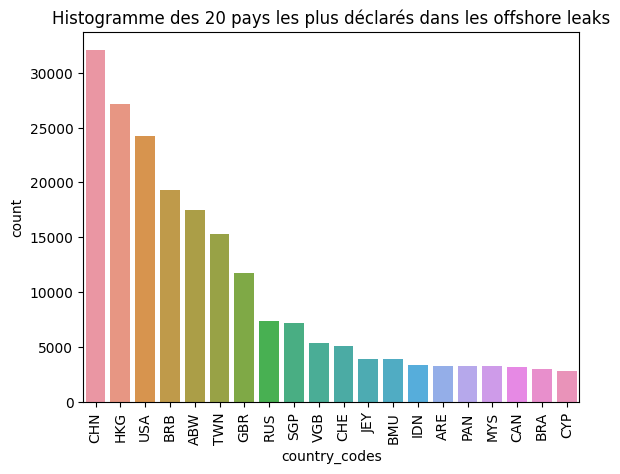

In [79]:
sns.countplot(x="country_codes", order=address["country_codes"].value_counts().iloc[:20].index, data=address)
plt.xticks(rotation=90)
plt.title("Histogramme des 20 pays les plus déclarés dans les offshore leaks")
plt.show()


5. Est on en présence d'une loi normale si non quel est le top 20 des pays les plus déclarrés ?



On utilise la bibliothèque shapiro pour vérifier si on est en présence d'une loi normale

In [80]:
nb_country_codes = address["country_codes"].value_counts()
stat, p_value = shapiro(nb_country_codes)
print(f"Statistique W : {stat:.4f}")
print(f"Valeur p : {p_value:.4f}")
alpha = 0.05
if p_value > alpha:
    print("Les données semblent suivre une distribution normale")
else:
    print("Les données ne semblent pas suivre une distribution normale")

Statistique W : 0.3158
Valeur p : 0.0000
Les données ne semblent pas suivre une distribution normale


On n'est pas en présence d'une loi normale

Top 20 des pays les plus déclarés

In [81]:
top = address["countries"].value_counts().head(20).to_dict()
print(top)

{'China': 32067, 'Hong Kong': 27179, 'United States': 24248, 'Barbados': 19344, 'Aruba': 17512, 'Taiwan': 15326, 'United Kingdom': 11706, 'Singapore': 7149, 'Russia': 5963, 'British Virgin Islands': 5282, 'Switzerland': 5113, 'Jersey': 3932, 'Bermuda': 3920, 'Indonesia': 3412, 'United Arab Emirates': 3283, 'Panama': 3257, 'Malaysia': 3241, 'Canada': 3139, 'Brazil': 2979, 'Cyprus': 2842}


EXERCICE 3

Info des colonnes des fichiers csv relationships, officers et entities

In [82]:
print("colonne de relationships:")
print(relationships.columns)
print()
print("colonne de officers:")
print(officers.columns)
print()
print("colonne de entities:")
print(entities.columns)

colonne de relationships:
Index(['_start', '_end', '_type', 'link', 'status', 'start_date', 'end_date',
       'sourceID'],
      dtype='object')

colonne de officers:
Index(['_id', 'node_id', 'name', 'countries', 'country_codes', 'sourceID',
       'valid_until', 'note'],
      dtype='object')

colonne de entities:
Index(['_id', 'node_id', 'name', 'original_name', 'former_name',
       'jurisdiction', 'jurisdiction_description', 'company_type', 'address',
       'internal_id', 'incorporation_date', 'inactivation_date',
       'struck_off_date', 'dorm_date', 'status', 'service_provider', 'ibcRUC',
       'country_codes', 'countries', 'sourceID', 'valid_until', 'note'],
      dtype='object')


6. Combien de service providers ont été déclarés dans les offshore leaks et quelle est la proportion de ces service providers vis-à-vis de des officers ?


On commence par trier le fichiers csv relationships en ne prenant que les _type officer_of


On merge le fichier officers avec le tri


Puis on merge l'ancien resultat avec le fichier entites


Puis on affiche le nombre de service_provider différent

In [83]:
relation_officer_of = relationships[relationships["_type"]=="officer_of"]

temp = pd.merge(officers, relation_officer_of, left_on="_id", right_on="_start")
res = pd.merge(temp, entities, left_on="_end", right_on="_id")

nb_provider = res["service_provider"].nunique()
print(nb_provider)


4


Il y a 4 service providers différents

On regarde le nombre d'officer

In [84]:
nb_officer = officers["_id"].nunique()
print(nb_officer)

746949


Il y a 746949 officers

On calcule la proportion

In [85]:
proportion = (nb_provider / nb_officer) * 100
print(proportion)

0.0005355117953166817


Le nombre de service provider represente 0.0005% des officers